# 5.2 Model Training & Stability Analysis

This notebook trains three classifiers on the preprocessed NSL-KDD dataset:

| Model | Key property |
|---|---|
| K-Nearest Neighbours (KNN) | Lazy learner, distance-based, K tuned via CV |
| Gaussian Naive Bayes (GNB) | Probabilistic, fast, assumes feature independence |
| SVM (RBF kernel) | Margin-based, trained on 25k stratified sample |

After training, **stability analysis** is performed using Repeated Stratified K-Fold CV (10×5 = 50 evaluations per model), followed by **learning curves**.

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from src.preprocess import preprocess
from src.train import (
    train_knn, train_nb, train_svm,
    stability_analysis, compute_learning_curves
)

sns.set_theme(style="whitegrid", palette="muted")
REPORT_DIR = "../reports"
os.makedirs(REPORT_DIR, exist_ok=True)

print('Imports OK')

Imports OK


## Load Preprocessed Data

In [2]:
X_train, X_test, y_train, y_test = preprocess(
    "../data/raw/KDDTrain.csv",
    "../data/raw/KDDTest.csv"
)

print(f"\nX_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"y_train: {y_train.value_counts().to_dict()}")
print(f"y_test : {y_test.value_counts().to_dict()}")

[load_data] Train: (125973, 42)  |  Test: (22543, 42)
[labels] Train → Normal: 67,343  Attack: 58,630
[labels] Test  → Normal: 9,710  Attack: 12,833
[encode] protocol_type   → 3 classes
[encode] service         → 70 classes
[encode] flag            → 11 classes
[normalise] Train range: [0.00, 1.00]
[normalise] Test  range: [0.0000, 2.5000]
[duplicates] ⚠️  758 test rows overlap with train.

[preprocess] Done. X_train: (125973, 41)  X_test: (22543, 41)

X_train: (125973, 41)  |  X_test: (22543, 41)
y_train: {0: 67343, 1: 58630}
y_test : {1: 12833, 0: 9710}


---
## Model 1 — K-Nearest Neighbours

KNN classifies a sample by majority vote among its K nearest neighbours in feature space. Since we scaled all features to [0,1], Euclidean distance is meaningful.

**K selection:** we evaluate odd values K ∈ {1, 3, 5, ..., 21} using 5-fold stratified CV and pick the K with highest mean F1.

In [18]:
knn_model, knn_metrics, knn_cv_scores, best_k = train_knn(
    X_train, y_train, X_test, y_test,
    k_range=range(1, 22, 2)
)

[tune_knn] Testing K = [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21] with 5-fold CV...
  K= 1  F1=0.9963 ± 0.0005
  K= 3  F1=0.9955 ± 0.0003
  K= 5  F1=0.9950 ± 0.0003
  K= 7  F1=0.9943 ± 0.0004
  K= 9  F1=0.9935 ± 0.0003
  K=11  F1=0.9930 ± 0.0006
  K=13  F1=0.9928 ± 0.0006
  K=15  F1=0.9925 ± 0.0006
  K=17  F1=0.9923 ± 0.0008
  K=19  F1=0.9921 ± 0.0006
  K=21  F1=0.9917 ± 0.0008

[tune_knn] Best K = 1  (F1 = 0.9963)

[train_knn] Fitting KNN with K=1...
[train_knn] Test results → Acc: 0.7924  P: 0.9743  R: 0.6526  F1: 0.7817


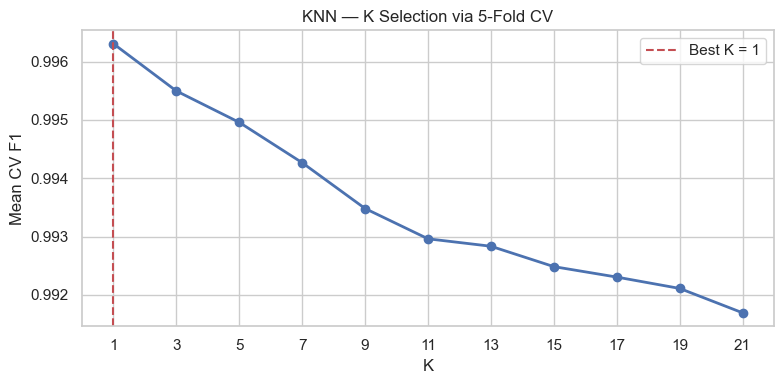

Best K = 1


In [19]:
# Plot K vs CV F1
fig, ax = plt.subplots(figsize=(8, 4))
ks = list(knn_cv_scores.keys())
fs = list(knn_cv_scores.values())
ax.plot(ks, fs, marker="o", color="#4C72B0", linewidth=2)
ax.axvline(best_k, color="#C44E52", linestyle="--",
           label=f"Best K = {best_k}")
ax.set_xlabel("K")
ax.set_ylabel("Mean CV F1")
ax.set_title("KNN — K Selection via 5-Fold CV")
ax.legend()
ax.set_xticks(ks)
plt.tight_layout()
plt.savefig(f"{REPORT_DIR}/knn_k_selection.png", dpi=150)
plt.show()
print(f"Best K = {best_k}")

---
## Model 2 — Gaussian Naive Bayes

GNB models each feature as a Gaussian distribution conditioned on the class label and computes posterior probability via Bayes' theorem. It assumes **conditional independence** between features — a strong assumption that rarely holds in practice, but often produces competitive results despite this.

In [20]:
nb_model, nb_metrics = train_nb(X_train, y_train, X_test, y_test)

[train_nb] Fitting Gaussian Naive Bayes...
[train_nb] Test results → Acc: 0.7709  P: 0.9161  R: 0.6578  F1: 0.7657


---
## Model 3 — Support Vector Machine (RBF kernel)

SVM finds the maximum-margin hyperplane separating classes in a high-dimensional feature space (via the kernel trick). The RBF kernel maps data into an infinite-dimensional space, making it powerful for non-linearly separable data.

**Runtime constraint:** SVM training is O(n²)–O(n³). Training on 125,973 rows would take hours. Standard practice is to use a representative stratified sample — we use **25,000 rows** (≈20% of training data), preserving class ratio.

**Grid search:** C ∈ {0.1, 1, 10} × gamma ∈ {scale, 0.01, 0.1} with 3-fold CV.

In [21]:
svm_model, svm_metrics, svm_best_params, svm_sample = train_svm(
    X_train, y_train, X_test, y_test,
    sample_size=25000,
    cv=3
)
print(f"Best SVM params: {svm_best_params}")

[train_svm] Sample size: 25,000  (Normal: 13,365  Attack: 11,635)
[train_svm] Running GridSearchCV (3-fold)...
Fitting 3 folds for each of 9 candidates, totalling 27 fits
[train_svm] Best params: {'C': 10, 'gamma': 'scale'}  (CV F1 = 0.9838)
[train_svm] Test results → Acc: 0.7932  P: 0.9739  R: 0.6542  F1: 0.7826
Best SVM params: {'C': 10, 'gamma': 'scale'}


---
## Results Summary — All Three Models

In [22]:
results_df = pd.DataFrame([
    {"Model": "KNN",          **{k: v for k, v in knn_metrics.items() if k not in ['confusion_matrix','y_pred']}},
    {"Model": "Naive Bayes",  **{k: v for k, v in nb_metrics.items()  if k not in ['confusion_matrix','y_pred']}},
    {"Model": "SVM",          **{k: v for k, v in svm_metrics.items() if k not in ['confusion_matrix','y_pred']}},
]).set_index("Model")

results_df = results_df[["accuracy","precision","recall","f1"]]
results_df.columns = ["Accuracy","Precision","Recall","F1"]
print(results_df.round(4).to_string())

             Accuracy  Precision  Recall      F1
Model                                           
KNN            0.7924     0.9743  0.6526  0.7817
Naive Bayes    0.7709     0.9161  0.6578  0.7657
SVM            0.7932     0.9739  0.6542  0.7826


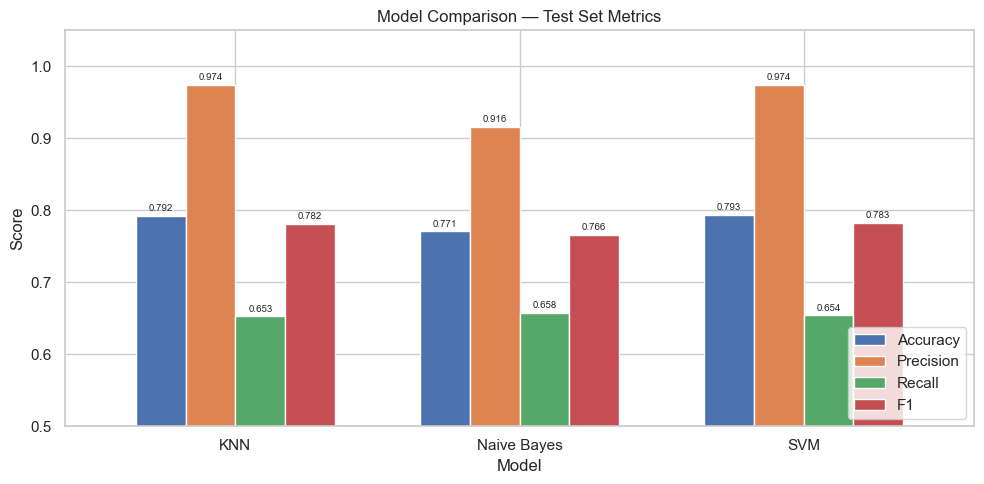

In [23]:
# Grouped bar chart
ax = results_df.plot(kind="bar", figsize=(10, 5), rot=0,
                     color=["#4C72B0","#DD8452","#55A868","#C44E52"],
                     edgecolor="white", width=0.7)
ax.set_ylim(0.5, 1.05)
ax.set_title("Model Comparison — Test Set Metrics")
ax.set_ylabel("Score")
ax.legend(loc="lower right")
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=7, padding=2)
plt.tight_layout()
plt.savefig(f"{REPORT_DIR}/model_comparison.png", dpi=150)
plt.show()

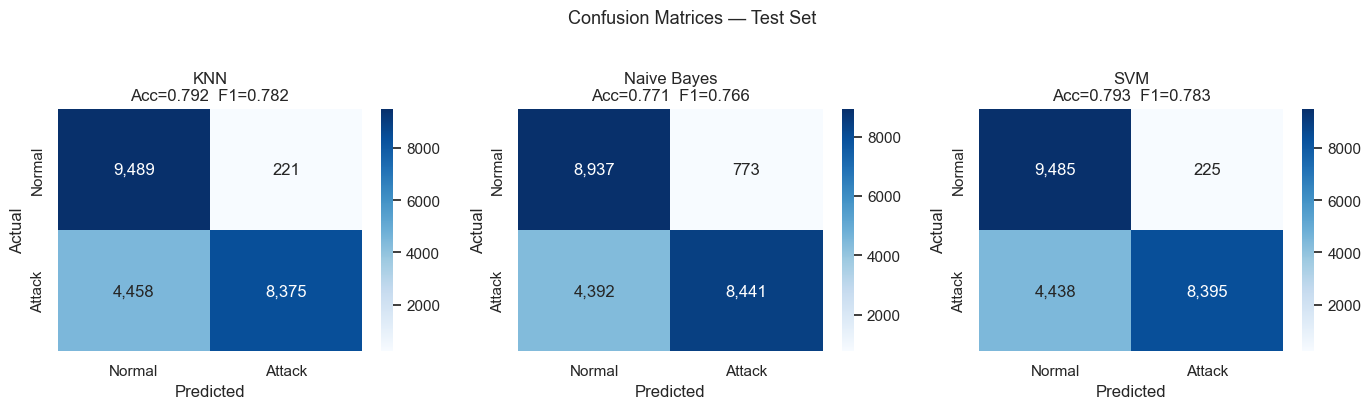

In [24]:
# Confusion matrices — side by side
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
model_names  = ["KNN", "Naive Bayes", "SVM"]
all_metrics  = [knn_metrics, nb_metrics, svm_metrics]

for ax, name, m in zip(axes, model_names, all_metrics):
    cm = m["confusion_matrix"]
    sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", ax=ax,
                xticklabels=["Normal","Attack"],
                yticklabels=["Normal","Attack"])
    ax.set_title(f"{name}\nAcc={m['accuracy']:.3f}  F1={m['f1']:.3f}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices — Test Set", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f"{REPORT_DIR}/confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Stability Analysis — Repeated Stratified K-Fold

A model that performs well on one test split but poorly on another is **unstable** — its metrics reflect the luck of the split, not genuine generalisation ability.

We use **Repeated Stratified K-Fold** (10 repeats × 5 folds = **50 evaluations per model**) to estimate the distribution of F1 scores across different data splits. Key statistics:

- **Mean F1** — central performance estimate
- **Std** — spread; lower is better
- **CV%** (Coefficient of Variation) — std / mean × 100; normalised instability measure. CV% < 2% → very stable, > 5% → unstable
- **Min / Max** — worst and best case

In [25]:
# Define unfitted model instances for stability analysis
# (stability_analysis fits them internally on each fold)
stability_models = {
    "KNN":         KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1),
    "Naive Bayes": GaussianNB(),
    "SVM":         SVC(kernel="rbf",
                       C=svm_best_params["C"],
                       gamma=svm_best_params["gamma"],
                       class_weight="balanced",
                       random_state=42),
}

stability_df, raw_scores = stability_analysis(
    stability_models,
    X_train, y_train,
    n_splits=5,
    n_repeats=10,
    scoring="f1",
    svm_sample_size=25000,
)

[stability] Running 10×5-fold CV for KNN...
  → Mean=0.9965  Std=0.0004  CV%=0.04%
[stability] Running 10×5-fold CV for Naive Bayes...
  → Mean=0.8888  Std=0.0042  CV%=0.47%
[stability] Running 10×5-fold CV for SVM...
  → Mean=0.9848  Std=0.0015  CV%=0.15%


In [26]:
print("\nStability Summary (10×5 Repeated Stratified K-Fold):")
print(stability_df.set_index("Model").to_string())


Stability Summary (10×5 Repeated Stratified K-Fold):
             Mean F1     Std     Min     Max   CV%  n_evals
Model                                                      
KNN           0.9965  0.0004  0.9955  0.9974  0.04       50
Naive Bayes   0.8888  0.0042  0.8790  0.8953  0.47       50
SVM           0.9848  0.0015  0.9825  0.9894  0.15       50


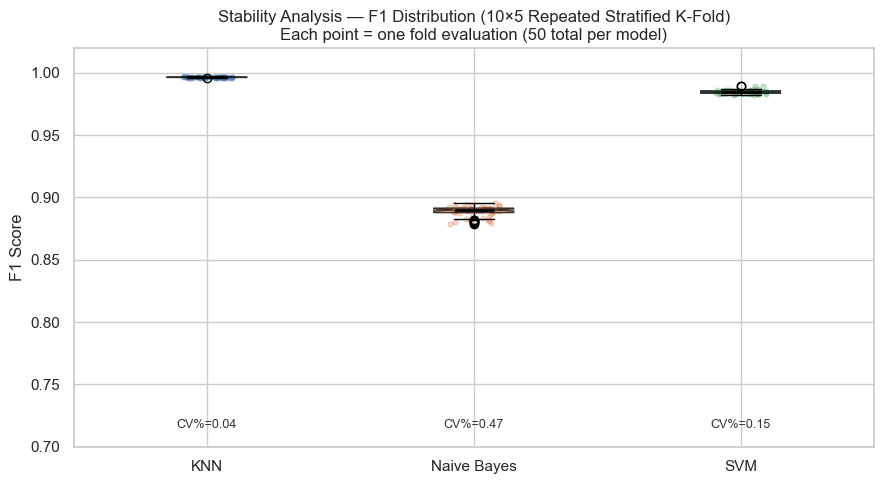

In [28]:
# Boxplot of F1 score distributions across 50 folds
fig, ax = plt.subplots(figsize=(9, 5))

score_data  = [raw_scores[m] for m in stability_models]
model_names = list(stability_models.keys())
colors      = ["#4C72B0", "#DD8452", "#55A868"]

bp = ax.boxplot(score_data, patch_artist=True, notch=True,
                medianprops=dict(color="black", linewidth=2))

for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

# Overlay individual points (jittered)
for i, scores in enumerate(score_data, start=1):
    jitter = np.random.default_rng(42).uniform(-0.1, 0.1, len(scores))
    ax.scatter(np.full(len(scores), i) + jitter, scores,
               alpha=0.3, s=12, color=colors[i-1])

ax.set_xticks(range(1, len(model_names)+1))
ax.set_xticklabels(model_names)
ax.set_ylabel("F1 Score")
ax.set_title("Stability Analysis — F1 Distribution (10×5 Repeated Stratified K-Fold)\n"
             "Each point = one fold evaluation (50 total per model)")
ax.set_ylim(0.7, 1.02)

# Annotate CV%
for i, row in stability_df.iterrows():
    ax.text(i+1, 0.715, f"CV%={row['CV%']}",
            ha="center", fontsize=9, color="#333333")

plt.tight_layout()
plt.savefig(f"{REPORT_DIR}/stability_boxplot.png", dpi=150)
plt.show()

---
## Learning Curves

Learning curves show how F1 changes as the training set size increases. They reveal:
- **High bias (underfitting):** both train and val F1 are low and plateau early
- **High variance (overfitting):** large gap between train F1 (high) and val F1 (low)
- **Good fit:** train and val F1 converge at a high value

Note: SVM learning curves use a capped subset for runtime feasibility.

In [29]:
# Learning curves — KNN and NB on full train, SVM on 25k sample
lc_models = {
    "KNN":         KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1),
    "Naive Bayes": GaussianNB(),
}

curves = compute_learning_curves(
    lc_models, X_train, y_train,
    train_sizes=np.linspace(0.05, 1.0, 8),
    cv=5, scoring="f1"
)

# SVM learning curve on sample only
X_samp, y_samp = svm_sample
from src.train import compute_learning_curves as clc
svm_curves = clc(
    {"SVM": SVC(kernel="rbf", C=svm_best_params["C"],
                gamma=svm_best_params["gamma"],
                class_weight="balanced", random_state=42)},
    X_samp, y_samp,
    train_sizes=np.linspace(0.1, 1.0, 6),
    cv=3, scoring="f1"
)
curves.update(svm_curves)

[learning_curve] Computing for KNN...
  → Final val F1: 0.9963
[learning_curve] Computing for Naive Bayes...
  → Final val F1: 0.8887
[learning_curve] Computing for SVM...
  → Final val F1: 0.9838


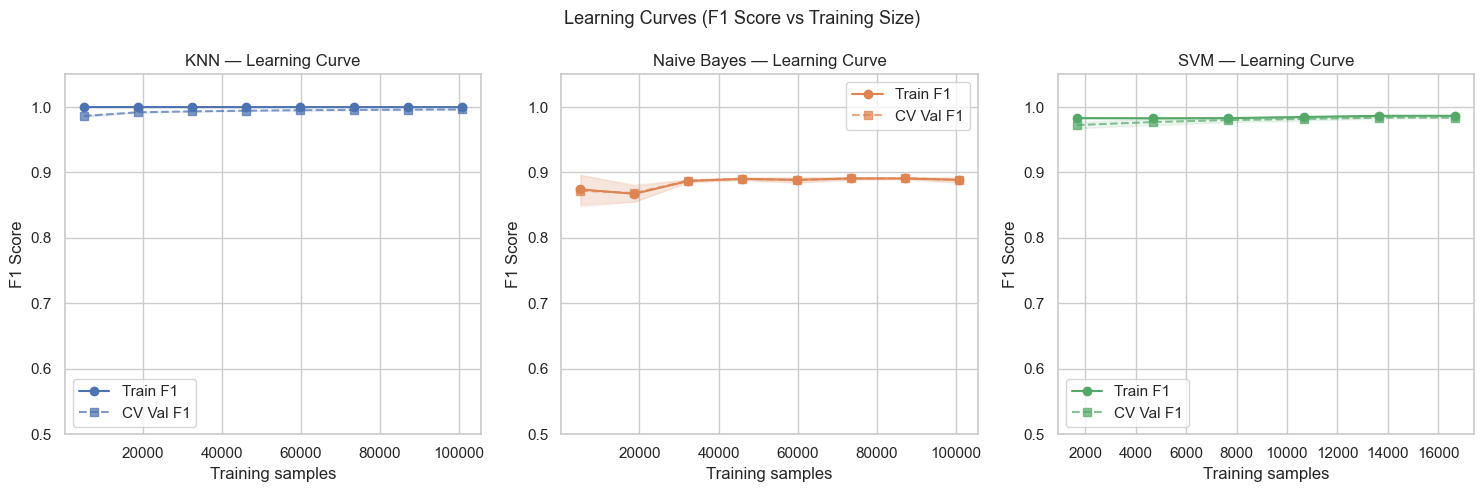

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors_map = {"KNN": "#4C72B0", "Naive Bayes": "#DD8452", "SVM": "#55A868"}

for ax, (name, (ts, tr, val)) in zip(axes, curves.items()):
    c = colors_map[name]
    tr_mean,  tr_std  = tr.mean(axis=1),  tr.std(axis=1)
    val_mean, val_std = val.mean(axis=1), val.std(axis=1)

    ax.plot(ts, tr_mean,  "o-", color=c,   label="Train F1")
    ax.plot(ts, val_mean, "s--", color=c,   label="CV Val F1", alpha=0.7)
    ax.fill_between(ts, tr_mean - tr_std,  tr_mean + tr_std,  alpha=0.1, color=c)
    ax.fill_between(ts, val_mean - val_std, val_mean + val_std, alpha=0.1, color=c)

    ax.set_title(f"{name} — Learning Curve")
    ax.set_xlabel("Training samples")
    ax.set_ylabel("F1 Score")
    ax.set_ylim(0.5, 1.05)
    ax.legend()

plt.suptitle("Learning Curves (F1 Score vs Training Size)", fontsize=13)
plt.tight_layout()
plt.savefig(f"{REPORT_DIR}/learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Section 5.2 Summary

In [31]:
print("=" * 60)
print("  SECTION 5.2 COMPLETE")
print("=" * 60)
print(f"  Best K (KNN)        : {best_k}")
print(f"  Best SVM params     : {svm_best_params}")
print()
print("  Test Set Metrics:")
print(results_df.round(4).to_string())
print()
print("  Stability (10×5 RSKF):")
print(stability_df.set_index("Model")[["Mean F1","Std","CV%"]].to_string())
print()
print("  Plots saved to ../reports/:")
for f in ["knn_k_selection","model_comparison","confusion_matrices",
          "stability_boxplot","learning_curves"]:
    print(f"    {f}.png")
print("=" * 60)
print("  → Pass models to notebooks/5_3_evaluation.ipynb")

  SECTION 5.2 COMPLETE
  Best K (KNN)        : 1
  Best SVM params     : {'C': 10, 'gamma': 'scale'}

  Test Set Metrics:
             Accuracy  Precision  Recall      F1
Model                                           
KNN            0.7924     0.9743  0.6526  0.7817
Naive Bayes    0.7709     0.9161  0.6578  0.7657
SVM            0.7932     0.9739  0.6542  0.7826

  Stability (10×5 RSKF):
             Mean F1     Std   CV%
Model                             
KNN           0.9965  0.0004  0.04
Naive Bayes   0.8888  0.0042  0.47
SVM           0.9848  0.0015  0.15

  Plots saved to ../reports/:
    knn_k_selection.png
    model_comparison.png
    confusion_matrices.png
    stability_boxplot.png
    learning_curves.png
  → Pass models to notebooks/5_3_evaluation.ipynb
